# QEdge6G Data Exploration

Load benchmark tables from `results/tables`, inspect the available scenarios, and visualize the main latency and throughput tradeoffs.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
tables = sorted(Path('../results/tables').glob('*.csv'))
tables

[PosixPath('../results/tables/edge_overload.csv'),
 PosixPath('../results/tables/edge_overload_smoke.csv'),
 PosixPath('../results/tables/mobility_event.csv'),
 PosixPath('../results/tables/sensitivity_sweep.csv'),
 PosixPath('../results/tables/smoke_wireless_dense.csv'),
 PosixPath('../results/tables/tcp_bursty.csv'),
 PosixPath('../results/tables/tenant_slicing.csv'),
 PosixPath('../results/tables/trace_replay.csv'),
 PosixPath('../results/tables/wireless_dense.csv')]

In [2]:
frames = []
for table in tables:
    df = pd.read_csv(table)
    df['source_file'] = table.name
    frames.append(df)
bench = pd.concat(frames, ignore_index=True)
bench.head()

,scenario_name,time_slot,solver_name,mean_latency_ms,p95_latency_ms,p99_latency_ms,throughput_mbps,goodput_mbps,packet_loss_rate,fairness_index,...,quality_gap,constraint_violation_count,dominant_bottleneck,admission_rate,metadata,source_file,traffic.num_users,topology.backhaul_capacity_mbps,ml.forecast_error_std,sweep_label
0,edge_overload,0,greedy,33.772528,37.628168,37.958381,135.030526,135.030526,0.0,0.628427,...,1.730353,0,edge,0.625,{},edge_overload.csv,NaN,NaN,NaN,NaN
1,edge_overload,1,greedy,36.977394,44.652844,45.506790,111.893185,111.893185,0.0,0.663181,...,0.534959,0,edge,0.750,{},edge_overload.csv,NaN,NaN,NaN,NaN
2,edge_overload,2,greedy,44.478211,52.048221,53.214728,123.575905,123.575905,0.0,0.729799,...,0.275182,0,edge,0.750,{},edge_overload.csv,NaN,NaN,NaN,NaN
3,edge_overload,3,greedy,45.772122,56.373506,57.173270,69.984452,69.984452,0.0,0.859440,...,0.007309,0,edge,0.625,{},edge_overload.csv,NaN,NaN,NaN,NaN
4,edge_overload,4,greedy,44.837650,54.313528,55.508832,84.209959,84.209959,0.0,0.718101,...,0.039668,0,edge,0.625,{},edge_overload.csv,NaN,NaN,NaN,NaN


In [3]:
summary = (
    bench.groupby(['scenario_name', 'solver_name'], as_index=False)
    .agg(
        mean_latency_ms=('mean_latency_ms', 'mean'),
        p95_latency_ms=('p95_latency_ms', 'mean'),
        goodput_mbps=('goodput_mbps', 'mean'),
        fairness_index=('fairness_index', 'mean'),
        solver_runtime_s=('solver_runtime_s', 'mean'),
    )
    .sort_values(['scenario_name', 'p95_latency_ms'])
)
summary

,scenario_name,solver_name,mean_latency_ms,p95_latency_ms,goodput_mbps,fairness_index,solver_runtime_s
3,edge_overload,milp_exact,22.915449,26.619538,47.654885,0.864309,0.015112
0,edge_overload,exact_small_scale,35.008255,42.943203,92.590728,0.717233,0.829086
1,edge_overload,greedy,35.649258,43.750720,90.012635,0.693522,0.000142
4,edge_overload,quantum_inspired,37.072176,46.436322,92.547801,0.690133,0.369516
6,edge_overload,simulated_annealing,44.289070,53.880353,116.295284,0.712631,0.274356
2,edge_overload,load_balanced,44.734065,55.421999,118.285164,0.702526,0.000148
5,edge_overload,shortest_path_nearest_edge,51.913006,61.299423,118.105041,0.800820,0.000154
9,mobility_event,load_balanced,15.448614,19.483787,167.300688,0.683281,0.000138
10,mobility_event,quantum_inspired,17.346826,23.992635,155.631808,0.665568,0.262490
7,mobility_event,exact_small_scale,18.603101,25.541692,159.996867,0.704122,0.029984


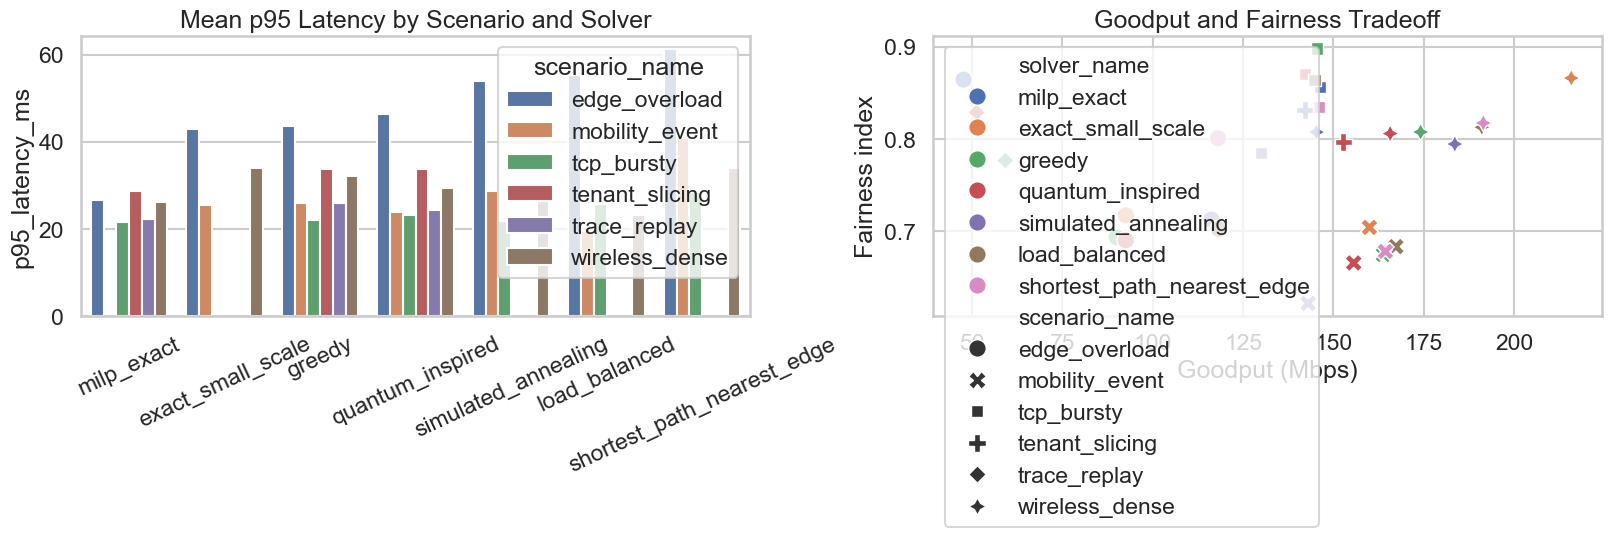

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.barplot(data=summary, x='solver_name', y='p95_latency_ms', hue='scenario_name', ax=axes[0])
axes[0].set_title('Mean p95 Latency by Scenario and Solver')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_xlabel('')

sns.scatterplot(data=summary, x='goodput_mbps', y='fairness_index', hue='solver_name', style='scenario_name', s=160, ax=axes[1])
axes[1].set_title('Goodput and Fairness Tradeoff')
axes[1].set_xlabel('Goodput (Mbps)')
axes[1].set_ylabel('Fairness index')
plt.show()

In [5]:
summary.pivot(index='solver_name', columns='scenario_name', values='p95_latency_ms').round(2)

scenario_name,edge_overload,mobility_event,tcp_bursty,tenant_slicing,trace_replay,wireless_dense
solver_name,,,,,,
exact_small_scale,42.94,25.54,NaN,NaN,NaN,33.98
greedy,43.75,25.99,22.00,33.78,26.04,32.15
load_balanced,55.42,19.48,25.79,NaN,NaN,23.20
milp_exact,26.62,NaN,21.70,28.77,22.39,26.27
quantum_inspired,46.44,23.99,23.31,33.78,24.41,29.48
shortest_path_nearest_edge,61.30,40.82,28.52,NaN,NaN,33.97
simulated_annealing,53.88,28.71,21.72,NaN,NaN,29.07
